<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/Skin_Cancer_Classification_Using_Hybrid_CNN_%2B_EfficientNetB3_%2B_Attention_architecture_on_the_HAM10000_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Multiply,
    Concatenate
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize


In [2]:
# =====================================================
# DATASET PATH
# =====================================================

base_path = "/content/drive/MyDrive/Skin Cancer MNIST HAM10000"

split_path = os.path.join(base_path, "split")

train_path = os.path.join(split_path, "train")
test_path  = os.path.join(split_path, "test")


In [3]:
# =====================================================
# IMAGE SETTINGS
# =====================================================

IMG_SIZE = 224
BATCH_SIZE = 32


In [4]:
# =====================================================
# DATA AUGMENTATION
# =====================================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [5]:
# =====================================================
# DATA LOADING
# =====================================================

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class Indices:")
print(train_generator.class_indices)


Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.
Class Indices:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [6]:
# =====================================================
# HYBRID CNN + EFFICIENTNETB3 + ATTENTION MODEL
# =====================================================

input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# =====================================================
# CNN BRANCH
# =====================================================

x = Conv2D(
    32,
    (3, 3),
    activation='relu',
    padding='same'
)(input_layer)

x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(
    64,
    (3, 3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(
    128,
    (3, 3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

cnn_features = GlobalAveragePooling2D()(x)

# =====================================================
# EFFICIENTNETB3 BRANCH
# =====================================================

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

y = base_model.output

y = GlobalAveragePooling2D()(y)

# =====================================================
# ATTENTION MODULE
# =====================================================

attention = Dense(
    1536,
    activation='relu'
)(y)

attention = Dense(
    1536,
    activation='sigmoid'
)(attention)

attention_features = Multiply()(
    [y, attention]
)

# =====================================================
# FEATURE FUSION
# =====================================================

combined = Concatenate()(
    [cnn_features, attention_features]
)

# =====================================================
# CLASSIFICATION HEAD
# =====================================================

z = Dense(
    512,
    activation='relu'
)(combined)

z = BatchNormalization()(z)

z = Dense(
    256,
    activation='relu'
)(z)

z = Dropout(0.5)(z)

output = Dense(
    train_generator.num_classes,
    activation='softmax',
    dtype='float32'
)(z)

model = Model(
    inputs=input_layer,
    outputs=output
)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [7]:
# =====================================================
# MODEL SUMMARY
# =====================================================

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 16,586,998 (63.27 MB)

 Trainable params: 9,356,161 (35.69 MB)

 Non-trainable params: 7,230,837 (27.58 MB)

In [8]:
# =====================================================
# COMPILE MODEL
# =====================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# =====================================================
# CALLBACKS
# =====================================================

callbacks = [

    EarlyStopping(
        patience=6,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        patience=3,
        factor=0.3,
        verbose=1
    ),

    ModelCheckpoint(
        "ham10000_hybrid_best.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


In [10]:
# =====================================================
# TRAIN MODEL
# =====================================================

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4867 - loss: 1.6064
Epoch 1: val_accuracy improved from None to 0.71343, saving model to ham10000_hybrid_best.h5



Epoch 1: finished saving model to ham10000_hybrid_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 3722s 13s/step - accuracy: 0.6081 - loss: 1.1983 - val_accuracy: 0.7134 - val_loss: 0.8564 - learning_rate: 1.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7040 - loss: 0.8467
Epoch 2: val_accuracy improved from 0.71343 to 0.75537, saving model to ham10000_hybrid_best.h5



Epoch 2: finished saving model to ham10000_hybrid_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1943s 8s/step - accuracy: 0.7119 - loss: 0.8270 - val_accuracy: 0.7554 - val_loss: 0.6967 - learning_rate: 1.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7327 - loss: 0.7527
Epoch 3: val_accuracy improved from 0.75537 to 0.77783, saving model to ham10000_hybrid_best.h5



Epoch 3: finished saving model to ham10000_hybrid_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1962s 8s/step - accuracy: 0.7409 - loss: 0.7293 - val_accuracy: 0.7778 - val_loss: 0.5868 - learning_rate: 1.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7662 - loss: 0.6701
Epoch 4: val_accuracy improved from 0.77783 to 0.78932, saving model to ham10000_hybrid_best.h5



Epoch 4: finished saving model to ham10000_hybrid_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1935s 8s/step - accuracy: 0.7649 - loss: 0.6678 - val_accuracy: 0.7893 - val_loss: 0.6000 - learning_rate: 1.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7728 - loss: 0.6249
Epoch 5: val_accuracy improved from 0.78932 to 0.79880, saving model to ham10000_hybrid_best.h5



Epoch 5: finished saving model to ham10000_hybrid_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1945s 8s/step - accuracy: 0.7761 - loss: 0.6290 - val_accuracy: 0.7988 - val_loss: 0.5712 - learning_rate: 1.0000e-04
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7935 - loss: 0.5790
Epoch 6: val_accuracy improved from 0.79880 to 0.80330, saving model to ham10000_hybrid_best.h5



Epoch 6: finished saving model to ham10000_hybrid_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1938s 8s/step - accuracy: 0.7903 - loss: 0.5780 - val_accuracy: 0.8033 - val_loss: 0.5479 - learning_rate: 1.0000e-04
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7884 - loss: 0.5745
Epoch 7: val_accuracy did not improve from 0.80330
251/251 ━━━━━━━━━━━━━━━━━━━━ 1917s 8s/step - accuracy: 0.7946 - loss: 0.5586 - val_accuracy: 0.7988 - val_loss: 0.5779 - learning_rate: 1.0000e-04
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7986 - loss: 0.5262
Epoch 8: val_accuracy improved from 0.80330 to 0.81927, saving model to ham10000_hybrid_best.h5



Epoch 8: finished saving model to ham10000_hybrid_best.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1969s 8s/step - accuracy: 0.8028 - loss: 0.5260 - val_accuracy: 0.8193 - val_loss: 0.5274 - learning_rate: 1.0000e-04
Epoch 9/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8027 - loss: 0.5218
Epoch 9: val_accuracy did not improve from 0.81927
251/251 ━━━━━━━━━━━━━━━━━━━━ 1970s 8s/step - accuracy: 0.8098 - loss: 0.5118 - val_accuracy: 0.8113 - val_loss: 0.5281 - learning_rate: 1.0000e-04
Epoch 10/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8224 - loss: 0.4765
Epoch 10: val_accuracy did not improve from 0.81927
251/251 ━━━━━━━━━━━━━━━━━━━━ 2083s 8s/step - accuracy: 0.8176 - loss: 0.4874 - val_accuracy: 0.8078 - val_loss: 0.5300 - learning_rate: 1.0000e-04


In [11]:
# ==========================================
# TEST ACCURACY
# ==========================================

test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.8193 - loss: 0.5274

Test Accuracy: 81.93%
Test Loss: 0.5274


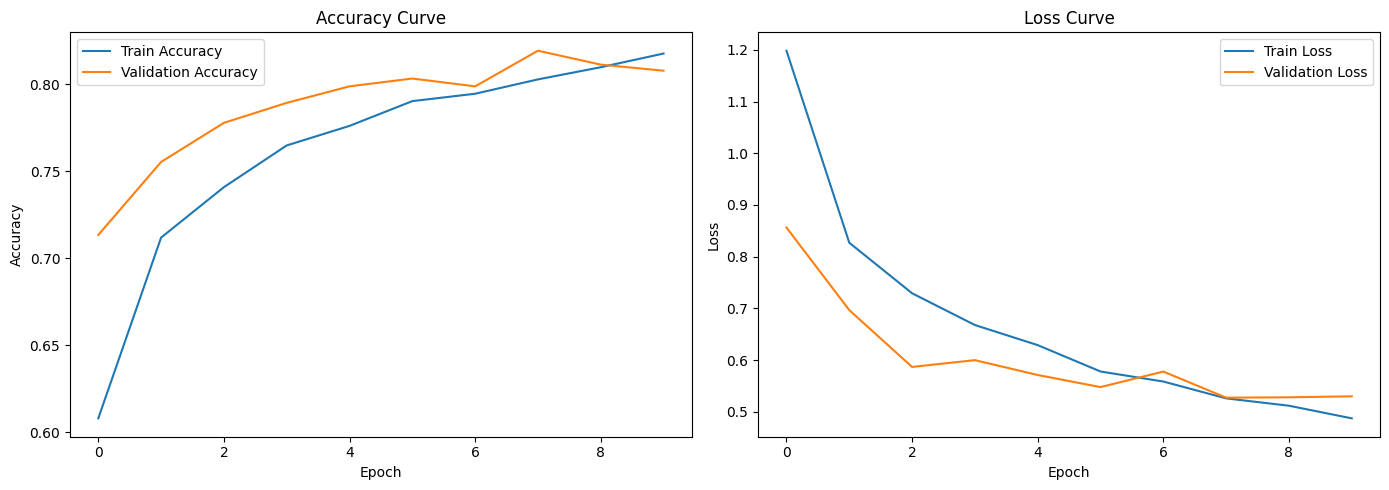

In [12]:
# ==========================================
# ACCURACY + LOSS CURVE
# ==========================================

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# PREDICTIONS
# ==========================================

test_generator.reset()

y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

63/63 ━━━━━━━━━━━━━━━━━━━━ 228s 4s/step


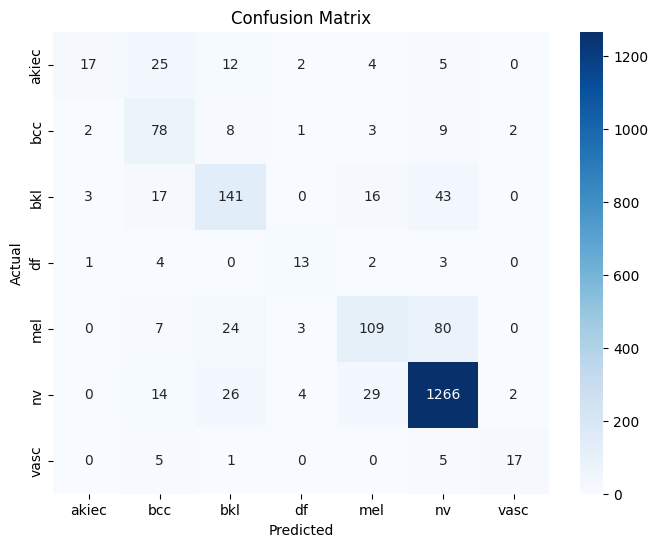

In [14]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


Classification Report:

              precision    recall  f1-score   support

       akiec       0.74      0.26      0.39        65
         bcc       0.52      0.76      0.62       103
         bkl       0.67      0.64      0.65       220
          df       0.57      0.57      0.57        23
         mel       0.67      0.49      0.56       223
          nv       0.90      0.94      0.92      1341
        vasc       0.81      0.61      0.69        28

    accuracy                           0.82      2003
   macro avg       0.69      0.61      0.63      2003
weighted avg       0.82      0.82      0.81      2003



In [16]:
from sklearn.metrics import f1_score

# ==========================================
# F1 SCORE
# ==========================================

f1_macro = f1_score(
    y_true,
    y_pred,
    average='macro'
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"\nMacro F1 Score    : {f1_macro:.4f}")
print(f"Weighted F1 Score : {f1_weighted:.4f}")


Macro F1 Score    : 0.6285
Weighted F1 Score : 0.8110


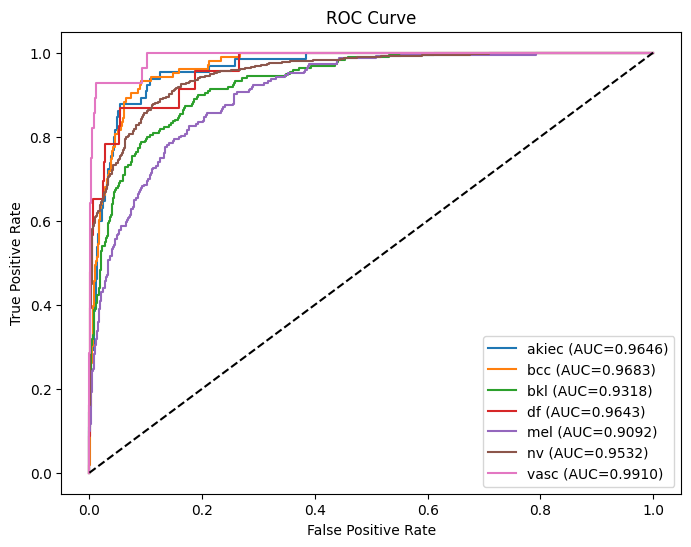

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ==========================================
# ROC CURVE
# ==========================================

num_classes = len(class_names)

y_true_bin = label_binarize(
    y_true,
    classes=range(num_classes)
)

plt.figure(figsize=(8,6))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{class_names[i]} (AUC={roc_auc:.4f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

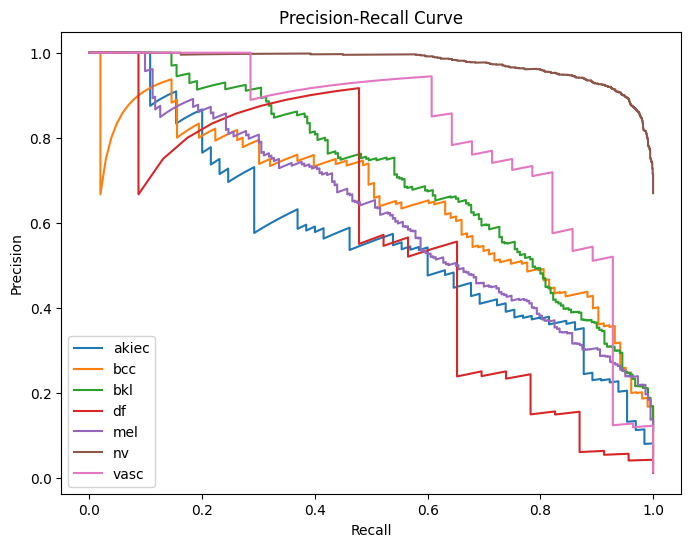

In [18]:
from sklearn.metrics import precision_recall_curve

# ==========================================
# PRECISION-RECALL CURVE
# ==========================================

plt.figure(figsize=(8,6))

for i in range(num_classes):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=class_names[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

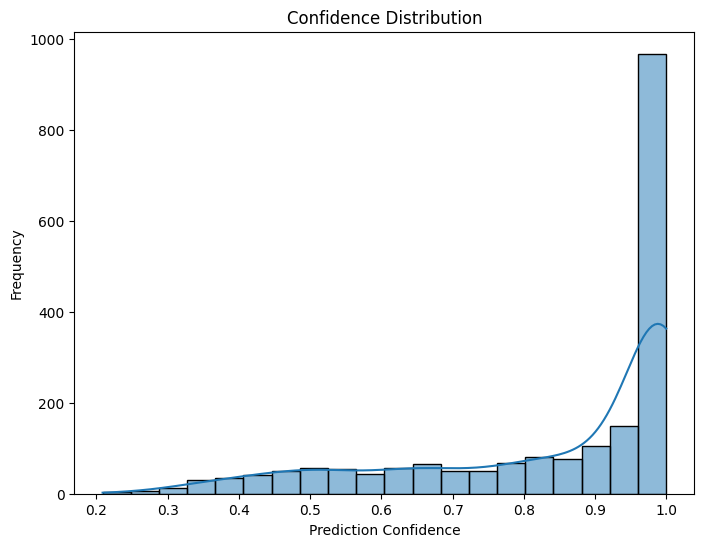

In [19]:
# ==========================================
# CONFIDENCE DISTRIBUTION
# ==========================================

confidence_scores = np.max(
    y_pred_prob,
    axis=1
)

plt.figure(figsize=(8,6))

sns.histplot(
    confidence_scores,
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution")
plt.show()